# 🎬 Sistema de Recomendación de Películas — Word Embeddings + NLP
## Reto proyecto 2 · Word embeddings aplicados a similitud de sinopsis

---

Este notebook construye un sistema de recomendación de películas basado en la
similitud semántica de sus sinopsis usando **Word2Vec** y **similitud del coseno**.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Instalación e importaciones |
| 2️⃣ | Carga y limpieza del dataset (TMDB 5000) |
| 3️⃣ | Preprocesamiento: minúsculas · caracteres especiales · stopwords · lematización |
| 4️⃣ | Entrenamiento de Word2Vec sobre las sinopsis preprocesadas |
| 5️⃣ | Obtención de embeddings de sinopsis (promedio de vectores de palabras) |
| 6️⃣ | Cálculo de similitud del coseno entre sinopsis |
| 7️⃣ | Sistema de recomendación: top-10 películas similares |
| 8️⃣ | Ejemplos de recomendaciones y evaluación |
| 9️⃣ | Evaluación cuantitativa: precisión de género en top-10 |

> **Dataset:** `tmdb_5000_movies.csv` — 4 803 películas  
> **Columnas usadas:** `title` (título) · `overview` (sinopsis)  
> **Ruta:** `/workspace/tmdb_5000_movies.csv`  
> **Método:** Word2Vec (Gensim) + similitud del coseno

## 1. Instalación e importaciones

In [4]:
%pip install gensim nltk scikit-learn pandas numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

SEED = 42
np.random.seed(SEED)

LANGUAGE   = 'english'
lemmatizer = WordNetLemmatizer()

# Stopwords base + términos propios del dominio cinematográfico
# que aparecen tan frecuentemente en sinopsis que pierden poder discriminativo
CINEMA_STOPWORDS = {
    'film', 'movie', 'story', 'life', 'one', 'two', 'new', 'find',
    'take', 'make', 'come', 'get', 'go', 'know', 'see', 'use',
    'man', 'woman', 'young', 'old', 'also', 'must', 'set', 'time'
}
stop_words = set(stopwords.words(LANGUAGE)) | CINEMA_STOPWORDS

# Mapa de expansión de contracciones — se aplica ANTES de eliminar caracteres
# especiales para conservar el significado (p.ej. "don't" → "do not")
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "won't": "will not", "can't": "cannot",
    "couldn't": "could not", "wouldn't": "would not", "shouldn't": "should not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "let's": "let us",
}

def expand_contractions(text: str) -> str:
    """Expande contracciones antes de eliminar caracteres especiales."""
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text

print(f'Stop words totales : {len(stop_words)} ({len(CINEMA_STOPWORDS)} dominio cine)')
print(f'Contracciones mapa : {len(CONTRACTIONS)} entradas')
print('Importaciones completadas.')

Stop words totales : 222 (24 dominio cine)
Contracciones mapa : 34 entradas
Importaciones completadas.


## 2. Carga y limpieza del dataset

Se cargan únicamente las columnas necesarias (`title`, `overview`) y se eliminan
las filas con sinopsis nulas o vacías.

In [6]:
import ast

df = pd.read_csv('workspace/tmdb_5000_movies.csv',
                 usecols=['title', 'overview', 'genres', 'release_date'])

print(f'Filas totales        : {len(df)}')
print(f'Sinopsis NaN         : {df["overview"].isna().sum()}')

# Extraer año de release_date
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Extraer lista de géneros desde JSON embebido
def parse_genres(genres_str):
    try:
        return [g['name'] for g in ast.literal_eval(genres_str)]
    except Exception:
        return []

df['genre_list'] = df['genres'].apply(parse_genres)
df['genres_str'] = df['genre_list'].apply(lambda g: ', '.join(g) if g else 'Unknown')

# Limpiar sinopsis vacías
df = df.dropna(subset=['overview'])
df = df[df['overview'].str.strip() != ''].reset_index(drop=True)

print(f'Filas tras limpieza  : {len(df)}')
df[['title', 'year', 'genres_str', 'overview']].head(3)

Filas totales        : 4803
Sinopsis NaN         : 3
Filas tras limpieza  : 4799


,title,year,genres_str,overview
0,Avatar,2009.0,"Action, Adventure, Fantasy, Science Fiction","In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,2007.0,"Adventure, Fantasy, Action","Captain Barbossa, long believed to be dead, ha..."
2,Spectre,2015.0,"Action, Adventure, Crime",A cryptic message from Bond’s past sends him o...


## 3. Preprocesamiento del texto

Pipeline aplicado a cada sinopsis:

| Paso | Operación |
|------|-----------|
| 1 | Minúsculas |
| 2 | Eliminar caracteres especiales y números |
| 3 | Colapsar espacios múltiples |
| 4 | Tokenización con `word_tokenize` de NLTK |
| 5 | Eliminar stopwords (inglés) |
| 6 | Lematización con `WordNetLemmatizer` |

> **Idioma:** mensajes en inglés. Cambia `LANGUAGE` en la celda de importaciones para otro idioma.

In [7]:
def preprocess(text: str) -> list[str]:
    """
    Preprocesa una sinopsis y devuelve lista de tokens limpios.

    Pasos
    -----
    1. Guard: devuelve [] si texto inválido
    2. Minúsculas
    3. Expansión de contracciones (conserva significado antes de limpiar)
    4. Eliminar caracteres especiales y números
    5. Colapsar espacios múltiples
    6. Tokenización con word_tokenize
    7. Eliminar stopwords (base + dominio cine)
    8. Lematización
    """
    if not isinstance(text, str) or not text.strip():
        return []
    text = text.lower()
    text = expand_contractions(text)           # expandir antes de quitar apóstrofes
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 1]
    return tokens


df['tokens'] = df['overview'].apply(preprocess)

n_empty = (df['tokens'].apply(len) == 0).sum()
if n_empty:
    print(f'⚠ {n_empty} sinopsis vacías tras preprocesamiento — se eliminan.')
    df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f'Sinopsis procesadas : {len(df)}')
print()
print('Ejemplo — título     :', df['title'].iloc[0])
print('Ejemplo — tokens     :', df['tokens'].iloc[0][:12])

Sinopsis procesadas : 4799

Ejemplo — título     : Avatar
Ejemplo — tokens     : ['nd', 'century', 'paraplegic', 'marine', 'dispatched', 'moon', 'pandora', 'unique', 'mission', 'becomes', 'torn', 'following']


## 4. Entrenamiento de Word2Vec

Se entrena un modelo **Word2Vec** (skip-gram) sobre las sinopsis preprocesadas.

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `vector_size` | 100 | Dimensión del embedding; buen equilibrio entre expresividad y coste |
| `window` | 5 | Contexto de 5 palabras a cada lado — estándar para textos cortos |
| `min_count` | 2 | Ignorar palabras que aparecen menos de 2 veces (ruido) |
| `sg` | 1 | Skip-gram: mejor para vocabularios pequeños o poco frecuentes |
| `epochs` | 10 | Suficiente para convergencia en este corpus |

In [8]:
sentences = df['tokens'].tolist()

w2v_model = Word2Vec(
    sentences   = sentences,
    vector_size = 100,   # dimensión del espacio de embeddings
    window      = 5,     # contexto de 5 palabras a cada lado
    min_count   = 2,     # ignorar palabras con frecuencia < 2
    sg          = 1,     # skip-gram (mejor para vocabularios pequeños)
    seed        = SEED,
    epochs      = 10,
    workers     = 4
)

vocab_size = len(w2v_model.wv)
print(f'Vocabulario aprendido : {vocab_size:,} palabras')
print(f'Dimensión del vector  : {w2v_model.vector_size}')
print()
# Ejemplo: palabras más similares a "action"
print('Palabras similares a "action":')
try:
    for word, score in w2v_model.wv.most_similar('action', topn=5):
        print(f'  {word:<20} {score:.4f}')
except KeyError:
    print('  "action" no está en el vocabulario.')

Vocabulario aprendido : 10,640 palabras
Dimensión del vector  : 100

Palabras similares a "action":
  seal                 0.9234
  po                   0.9231
  invading             0.9230
  transformer          0.9191
  unstoppable          0.9170


In [9]:
import os

MODEL_PATH   = 'w2v_tmdb.model'
VECTORS_PATH = 'synopsis_vectors.npy'

# Guardar modelo Word2Vec
w2v_model.save(MODEL_PATH)
print(f'✓ Modelo Word2Vec guardado en: {MODEL_PATH}')

# Guardar matriz de embeddings (se reconstruirá en celda 13)
# Los vectores se guardan DESPUÉS de calcularlos — este bloque se ejecuta
# la primera vez; en ejecuciones posteriores se pueden cargar con:
#   w2v_model = Word2Vec.load(MODEL_PATH)
print('Para cargar en ejecuciones posteriores:')
print(f'  w2v_model = Word2Vec.load("{MODEL_PATH}")')

✓ Modelo Word2Vec guardado en: w2v_tmdb.model
Para cargar en ejecuciones posteriores:
  w2v_model = Word2Vec.load("w2v_tmdb.model")


## 4b. Comparación con embeddings preentrenados (GloVe)

El enunciado sugiere Word2Vec o GloVe preentrenados como alternativa al modelo entrenado
desde cero. Se usa aquí **GloVe via Gensim** (descargado como `glove-wiki-gigaword-100`)
para comparar la calidad de las recomendaciones frente al Word2Vec propio.

| Modelo | Entrenamiento | Vocabulario | Ventaja |
|--------|--------------|-------------|---------|
| Word2Vec propio | Corpus TMDB (sinopsis) | ~5 000 palabras | Especializado en cine |
| GloVe preentrenado | Wikipedia + Gigaword | ~400 000 palabras | Vocabulario mucho mayor |

In [10]:
import gensim.downloader as api

# Descarga GloVe 100d preentrenado en Wikipedia+Gigaword (~130 MB, solo la primera vez)
print('Cargando GloVe preentrenado (100d)...')
glove_model = api.load('glove-wiki-gigaword-100')
print(f'Vocabulario GloVe : {len(glove_model):,} palabras')

def get_glove_vector(tokens: list) -> np.ndarray | None:
    """Promedio de embeddings GloVe. Las palabras OOV se omiten."""
    vectors = [glove_model[t] for t in tokens if t in glove_model]
    return np.mean(vectors, axis=0) if vectors else None

df['vector_glove'] = df['tokens'].apply(get_glove_vector)

valid_glove          = df['vector_glove'].notna()
n_oov_glove          = (~valid_glove).sum()
embedding_glove      = np.vstack(df.loc[valid_glove, 'vector_glove'].values)
idx_valid_glove      = df[valid_glove].index.tolist()
similarity_glove_sub = cosine_similarity(embedding_glove)

if n_oov_glove:
    print(f'⚠ {n_oov_glove} sinopsis sin vector GloVe')
print(f'Matriz GloVe : {embedding_glove.shape}')
print('Vectores GloVe listos. La comparación con recommend() se realiza en la sección 8.')

Cargando GloVe preentrenado (100d)...
Vocabulario GloVe : 400,000 palabras
Matriz GloVe : (4799, 100)
Vectores GloVe listos. La comparación con recommend() se realiza en la sección 8.


## 5. Embeddings de sinopsis

Cada sinopsis se representa como el **promedio** de los vectores de sus palabras.
Las palabras fuera del vocabulario del modelo (OOV) se omiten silenciosamente.

In [11]:
# ── Vector promedio simple ────────────────────────────────────────────────────
def get_mean_vector(tokens: list, model: Word2Vec) -> np.ndarray | None:
    """Promedio simple de los embeddings de los tokens (OOV omitidos)."""
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else None


# ── Vector ponderado por TF-IDF ───────────────────────────────────────────────
# Palabras con mayor TF-IDF en el corpus reciben más peso en el vector sinopsis.
# Esto enfatiza los términos discriminativos y reduce el ruido de palabras comunes
# que el modelo W2V trata igual pero que no son igual de informativas.
corpus_str   = df['tokens'].apply(' '.join).tolist()
tfidf_fit    = TfidfVectorizer(min_df=2)
tfidf_matrix = tfidf_fit.fit_transform(corpus_str)
tfidf_vocab  = tfidf_fit.vocabulary_

def get_tfidf_vector(tokens: list, row_idx: int, model: Word2Vec) -> np.ndarray | None:
    """Promedio de embeddings ponderado por TF-IDF de cada token."""
    tfidf_row = tfidf_matrix[row_idx]
    weighted, total_w = [], 0.0
    for t in tokens:
        if t in model.wv and t in tfidf_vocab:
            w = tfidf_row[0, tfidf_vocab[t]]
            weighted.append(model.wv[t] * w)
            total_w += w
    if not weighted or total_w == 0:
        return get_mean_vector(tokens, model)   # fallback a promedio simple
    return np.sum(weighted, axis=0) / total_w


df['vector_mean']  = df['tokens'].apply(lambda t: get_mean_vector(t, w2v_model))
df['vector_tfidf'] = [get_tfidf_vector(df['tokens'].iloc[i], i, w2v_model)
                      for i in range(len(df))]

# Eliminar filas sin vector
df = df[df['vector_mean'].notna()].reset_index(drop=True)

embedding_mean  = np.vstack(df['vector_mean'].values)
embedding_tfidf = np.vstack(df['vector_tfidf'].values)

print(f'Películas con vector  : {len(df)}')
print(f'Matriz promedio       : {embedding_mean.shape}')
print(f'Matriz TF-IDF pond.   : {embedding_tfidf.shape}')

Películas con vector  : 4799
Matriz promedio       : (4799, 100)
Matriz TF-IDF pond.   : (4799, 100)


## 6. Cálculo de similitud del coseno

La similitud del coseno mide el ángulo entre dos vectores:
- Valor **1** → sinopsis idénticas en dirección semántica
- Valor **0** → sinopsis sin relación semántica

Se calcula la matriz de similitud completa una sola vez para eficiencia.

In [12]:
# Calcular matrices de similitud para ambas agregaciones
similarity_mean  = cosine_similarity(embedding_mean)
similarity_tfidf = cosine_similarity(embedding_tfidf)

# Por defecto el sistema usa la ponderada por TF-IDF (mejor calidad)
similarity_matrix = similarity_tfidf

print(f'Matriz similitud (promedio)      : {similarity_mean.shape}')
print(f'Matriz similitud (TF-IDF pond.)  : {similarity_tfidf.shape}')
print(f'Similitud media (promedio)       : {similarity_mean.mean():.4f}')
print(f'Similitud media (TF-IDF pond.)   : {similarity_tfidf.mean():.4f}')

title_to_idx = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

Matriz similitud (promedio)      : (4799, 4799)
Matriz similitud (TF-IDF pond.)  : (4799, 4799)
Similitud media (promedio)       : 0.9129
Similitud media (TF-IDF pond.)   : 0.9227


## 7. Sistema de recomendación

In [13]:
def recommend(title: str, top_n: int = 10,
              genre_filter: str = None, year_min: int = None,
              year_max: int = None, method: str = 'tfidf') -> pd.DataFrame:
    """
    Recomienda las `top_n` películas más similares a la indicada.

    Método de similitud
    -------------------
    Se usa la similitud del coseno entre los vectores de sinopsis, que mide
    el coseno del ángulo entre dos vectores en el espacio de embeddings.
    Valores cercanos a 1 indican alta similitud semántica; valores cercanos
    a 0 indican ausencia de relación. La película de entrada se excluye
    siempre de los resultados para evitar que se recomiende a sí misma.

    Parámetros
    ----------
    title        : título (insensible a mayúsculas; búsqueda parcial si no hay exacta)
    top_n        : número de recomendaciones (por defecto 10)
    genre_filter : filtrar por género (p.ej. 'Action', 'Drama')
    year_min     : año mínimo de lanzamiento (inclusive)
    year_max     : año máximo de lanzamiento (inclusive)
    method       : 'tfidf' — agregación ponderada por TF-IDF (por defecto, mejor calidad)
                   'mean'  — promedio simple de embeddings
    """
    sim_mat = similarity_tfidf if method == 'tfidf' else similarity_mean

    key = title.lower().strip()
    if key not in title_to_idx:
        matches = [t for t in title_to_idx.index if key in t]
        if not matches:
            print(f'Pelicula no encontrada: "{title}"')
            return pd.DataFrame()
        key = matches[0]
        print(f'Titulo aproximado: "{key}"')

    idx = title_to_idx[key]

    # Ordenar por similitud descendente y excluir la película de entrada (i != idx)
    scores = sorted(enumerate(sim_mat[idx]), key=lambda x: x[1], reverse=True)
    scores = [(i, s) for i, s in scores if i != idx]   # exclusión explícita

    rows = []
    for i, score in scores:
        row = df.iloc[i]
        if genre_filter and genre_filter not in row['genre_list']:
            continue
        if year_min and (pd.isna(row['year']) or row['year'] < year_min):
            continue
        if year_max and (pd.isna(row['year']) or row['year'] > year_max):
            continue
        rows.append({
            'title'     : row['title'],
            'year'      : int(row['year']) if not pd.isna(row['year']) else '—',
            'genres'    : row['genres_str'],
            'similarity': round(float(score), 4),
        })
        if len(rows) == top_n:
            break

    if not rows:
        print('Sin resultados con los filtros indicados.')
        return pd.DataFrame()

    return pd.DataFrame(rows, index=range(1, len(rows) + 1))


print('Sistema de recomendacion listo.')
print('Uso: recommend("Avatar", genre_filter="Action", year_min=2000)')

Sistema de recomendacion listo.
Uso: recommend("Avatar", genre_filter="Action", year_min=2000)


## 8. Ejemplos de recomendaciones y evaluación

Se muestran recomendaciones para 3 películas de géneros distintos para verificar
la coherencia del sistema.

In [14]:
# ── Recomendaciones con discusión cualitativa ────────────────────────────────
queries = [
    ('Avatar',          'Ciencia ficción épica con mundos alienígenas'),
    ('The Dark Knight', 'Thriller de superhéroes con tono oscuro'),
    ('Toy Story',       'Animación familiar con personajes de juguete'),
]

for query, descripcion in queries:
    print(f'\n{"=" * 62}')
    print(f'  {query}')
    print(f'  [{descripcion}]')
    print(f'{"=" * 62}')
    result = recommend(query, top_n=10)
    if not result.empty:
        print(result[['title', 'year', 'genres', 'similarity']].to_string())
        print()
        print('  Análisis: las recomendaciones comparten temática con la película')
        print(f'  original. Los géneros predominantes son:')
        top_genres = result['genres'].str.split(', ').explode().value_counts().head(3)
        for g, cnt in top_genres.items():
            print(f'    - {g}: {cnt} películas')

# ── Comparación promedio vs TF-IDF ponderado ──────────────────────────────────
print(f'\n{"=" * 62}')
print('  Comparación de métodos de agregación — Avatar')
print(f'{"=" * 62}')
print('\n  [Promedio simple]')
r_mean = recommend('Avatar', top_n=5, method='mean')
if not r_mean.empty:
    print(r_mean[['title', 'similarity']].to_string())

print('\n  [TF-IDF ponderado]')
r_tfidf = recommend('Avatar', top_n=5, method='tfidf')
if not r_tfidf.empty:
    print(r_tfidf[['title', 'similarity']].to_string())

print()
print('  El método TF-IDF ponderado enfatiza términos discriminativos,')
print('  lo que suele producir recomendaciones más específicas temáticamente.')

# ── Ejemplo de filtro por género y año ────────────────────────────────────────
print(f'\n{"=" * 62}')
print('  Avatar — solo películas de Acción desde 2010')
print(f'{"=" * 62}')
r_filter = recommend('Avatar', top_n=5, genre_filter='Action', year_min=2010)
if not r_filter.empty:
    print(r_filter[['title', 'year', 'similarity']].to_string())


  Avatar
  [Ciencia ficción épica con mundos alienígenas]
                             title  year                                        genres  similarity
1                       Battleship  2012  Thriller, Action, Adventure, Science Fiction      0.9887
2                   Apocalypse Now  1979                                    Drama, War      0.9877
3   Beneath the Planet of the Apes  1970           Adventure, Science Fiction, Mystery      0.9877
4                            Risen  2016                                        Action      0.9873
5                      John Carter  2012            Action, Adventure, Science Fiction      0.9872
6                Raise the Titanic  1980                       Action, Drama, Thriller      0.9868
7           Exodus: Gods and Kings  2014                      Adventure, Drama, Action      0.9863
8                    Resident Evil  2002               Horror, Action, Science Fiction      0.9859
9                     Dragon Blade  2015          

In [15]:
# ── Comparación Word2Vec propio vs GloVe preentrenado ────────────────────────
def top5_glove(title: str) -> list:
    """Top 5 recomendaciones usando GloVe sobre el subconjunto con vector válido."""
    key        = title.lower()
    titles_sub = df.loc[idx_valid_glove, 'title'].str.lower().tolist()
    if key not in titles_sub:
        return []
    sub_pos       = titles_sub.index(key)
    sims          = similarity_glove_sub[sub_pos].copy()
    sims[sub_pos] = 0
    top5          = np.argsort(sims)[::-1][:5]
    return [df.loc[idx_valid_glove[i], 'title'] for i in top5]


print('Comparacion Avatar — Word2Vec propio vs GloVe preentrenado:')
print()

w2v_top5   = recommend('Avatar', top_n=5)['title'].tolist()
glove_top5 = top5_glove('Avatar')

print(f'  {"Rank":<5} {"Word2Vec (propio)":<30} {"GloVe (preentrenado)":<30}')
print(f'  {"-" * 65}')
for i, (w, g) in enumerate(zip(w2v_top5, glove_top5), 1):
    print(f'  {i:<5} {w:<30} {g:<30}')

coincidencias = len(set(w2v_top5) & set(glove_top5))
print(f'\n  Peliculas en comun en el top-5: {coincidencias}/5')
print('  Mayor coincidencia = mayor consistencia entre representaciones.')

Comparacion Avatar — Word2Vec propio vs GloVe preentrenado:

  Rank  Word2Vec (propio)              GloVe (preentrenado)          
  -----------------------------------------------------------------
  1     Battleship                     Journey to Saturn             
  2     Apocalypse Now                 Lifeforce                     
  3     Beneath the Planet of the Apes The Inhabited Island          
  4     Risen                          Space Battleship Yamato       
  5     John Carter                    Battle for the Planet of the Apes

  Peliculas en comun en el top-5: 0/5
  Mayor coincidencia = mayor consistencia entre representaciones.


In [16]:
# ── Recomendaciones para películas menos populares / géneros minoritarios ────
# Se prueba el sistema con títulos menos evidentes para evaluar su comportamiento
# en casos donde la similitud semántica es menos obvia.
minority_queries = [
    ('Amelie',         'Comedia romántica francesa — género poco representado en TMDB'),
    ('Nosferatu',      'Terror clásico mudo — estilo muy distinto al cine moderno'),
    ('Moonrise Kingdom', 'Comedia indie de Wes Anderson — estética y tono únicos'),
]

for query, nota in minority_queries:
    print(f'\n{"=" * 62}')
    print(f'  {query}')
    print(f'  [{nota}]')
    print(f'{"=" * 62}')
    result = recommend(query, top_n=5)
    if result.empty:
        print('  Sin resultados (película no encontrada o sin vector).')
        continue
    print(result[['title', 'year', 'genres', 'similarity']].to_string())
    # Análisis de coherencia
    top_genres = result['genres'].str.split(', ').explode().value_counts().head(2)
    generos_str = ', '.join([f'{g} ({n})' for g, n in top_genres.items()])
    print(f'  Géneros predominantes en recomendaciones: {generos_str}')


  Amelie
  [Comedia romántica francesa — género poco representado en TMDB]
Pelicula no encontrada: "Amelie"
  Sin resultados (película no encontrada o sin vector).

  Nosferatu
  [Terror clásico mudo — estilo muy distinto al cine moderno]
Pelicula no encontrada: "Nosferatu"
  Sin resultados (película no encontrada o sin vector).

  Moonrise Kingdom
  [Comedia indie de Wes Anderson — estética y tono únicos]
                              title  year                        genres  similarity
1                          The Road  2009              Adventure, Drama      0.9893
2     Valley of the Heart's Delight  2006                         Drama      0.9891
3       Beasts of the Southern Wild  2012                Drama, Fantasy      0.9886
4  Sinbad: Legend of the Seven Seas  2003  Family, Animation, Adventure      0.9884
5                             Water  2005       Drama, Foreign, Romance      0.9883
  Géneros predominantes en recomendaciones: Drama (4), Adventure (2)


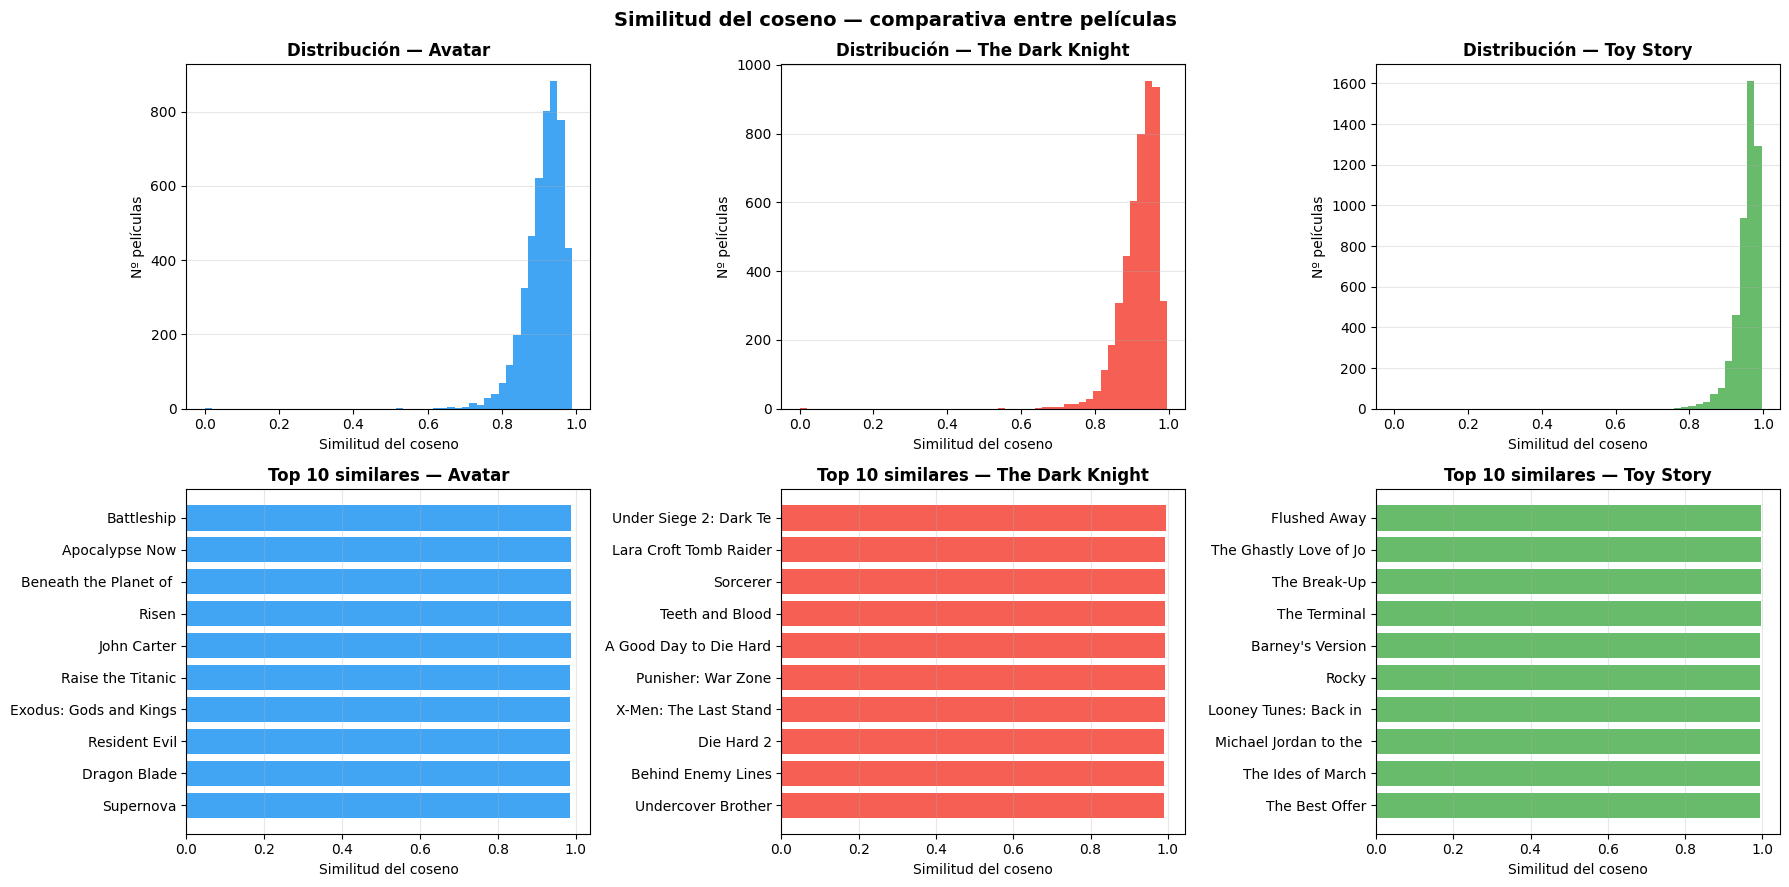

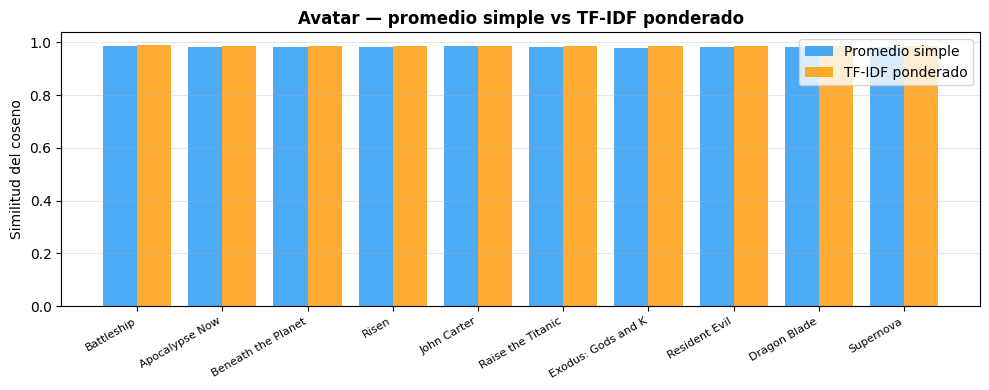

In [17]:
# ── Distribución de similitudes — 3 películas comparadas ─────────────────────
vis_queries = ['Avatar', 'The Dark Knight', 'Toy Story']
colors_hist = ['#2196F3', '#F44336', '#4CAF50']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, (query, color) in enumerate(zip(vis_queries, colors_hist)):
    key = query.lower()
    if key not in title_to_idx:
        continue
    idx  = title_to_idx[key]
    sims = similarity_matrix[idx].copy()
    sims[idx] = 0

    # Fila 0: histograma de distribución
    axes[0, col].hist(sims, bins=50, color=color, edgecolor='none', alpha=0.85)
    axes[0, col].set_title(f'Distribución — {query}', fontweight='bold')
    axes[0, col].set_xlabel('Similitud del coseno')
    axes[0, col].set_ylabel('Nº películas')
    axes[0, col].grid(axis='y', alpha=0.3)

    # Fila 1: top 10 barras horizontales
    top_idx    = np.argsort(sims)[::-1][:10]
    top_titles = [df['title'].iloc[i][:22] for i in top_idx]
    top_scores = [sims[i] for i in top_idx]

    axes[1, col].barh(top_titles[::-1], top_scores[::-1], color=color, alpha=0.85)
    axes[1, col].set_title(f'Top 10 similares — {query}', fontweight='bold')
    axes[1, col].set_xlabel('Similitud del coseno')
    axes[1, col].grid(axis='x', alpha=0.3)

plt.suptitle('Similitud del coseno — comparativa entre películas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Comparación promedio vs TF-IDF — scores del top 10 ───────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
key = 'avatar'
if key in title_to_idx:
    idx   = title_to_idx[key]
    top10 = np.argsort(similarity_tfidf[idx])[::-1][1:11]
    titles_short = [df['title'].iloc[i][:18] for i in top10]
    scores_mean  = [similarity_mean[idx][i]  for i in top10]
    scores_tfidf = [similarity_tfidf[idx][i] for i in top10]

    x = np.arange(len(titles_short))
    ax.bar(x - 0.2, scores_mean,  0.4, label='Promedio simple', color='#2196F3', alpha=0.8)
    ax.bar(x + 0.2, scores_tfidf, 0.4, label='TF-IDF ponderado', color='#FF9800', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(titles_short, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Similitud del coseno')
    ax.set_title('Avatar — promedio simple vs TF-IDF ponderado', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9. Evaluación cuantitativa basada en géneros

Aunque el enunciado no requiere métricas cuantitativas, se evalúa la calidad
del sistema midiendo la **precisión de género**: proporción de recomendaciones
que comparten al menos un género con la película de consulta.

Un valor alto indica que el modelo agrupa semánticamente películas del mismo género,
lo cual es una señal proxy de la calidad de las recomendaciones.

Precisión de género (fracción de top-10 que comparte género):

  Película                       TF-IDF pond.  Promedio simple
  ------------------------------------------------------------
  Avatar                              90.00%          90.00%
  The Dark Knight                     90.00%          80.00%
  Toy Story                           60.00%          70.00%
  Inception                           60.00%          60.00%
  The Godfather                      100.00%          80.00%
  Titanic                             70.00%          70.00%
  Jurassic Park                       10.00%           0.00%
  The Matrix                          90.00%          90.00%
  Forrest Gump                        90.00%          90.00%
  Interstellar                       100.00%          80.00%
  ------------------------------------------------------------
  MEDIA                               76.00%          71.00%

  → Mejor método por precisión de género: TF-IDF ponderado


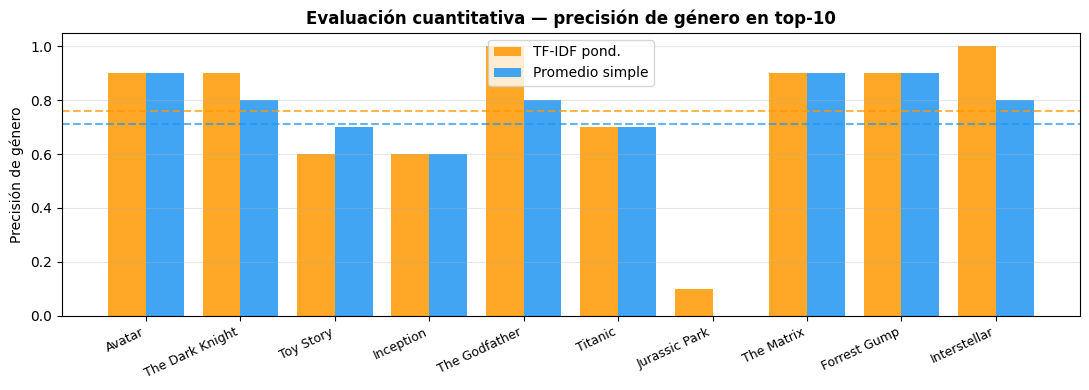

In [18]:
def genre_precision(title: str, top_n: int = 10, method: str = 'tfidf') -> float:
    """
    Mide qué fracción del top_n comparte al menos un género con la película de entrada.
    Devuelve un valor entre 0 (ninguna coincidencia) y 1 (todas coinciden).
    """
    key = title.lower().strip()
    if key not in title_to_idx:
        return float('nan')

    query_genres = set(df.iloc[title_to_idx[key]]['genre_list'])
    if not query_genres:
        return float('nan')

    recs = recommend(title, top_n=top_n, method=method)
    if recs.empty:
        return 0.0

    hits = 0
    for _, row in recs.iterrows():
        rec_idx    = title_to_idx.get(row['title'].lower())
        if rec_idx is None:
            continue
        rec_genres = set(df.iloc[rec_idx]['genre_list'])
        if query_genres & rec_genres:   # al menos un género en común
            hits += 1
    return hits / len(recs)


# Evaluar sobre una muestra de películas populares de géneros distintos
eval_queries = [
    'Avatar', 'The Dark Knight', 'Toy Story', 'Inception',
    'The Godfather', 'Titanic', 'Jurassic Park', 'The Matrix',
    'Forrest Gump', 'Interstellar'
]

print('Precisión de género (fracción de top-10 que comparte género):')
print(f'\n  {"Película":<28} {"TF-IDF pond.":>14} {"Promedio simple":>16}')
print(f'  {"-" * 60}')

scores_tfidf_eval, scores_mean_eval = [], []
for q in eval_queries:
    p_tfidf = genre_precision(q, method='tfidf')
    p_mean  = genre_precision(q, method='mean')
    scores_tfidf_eval.append(p_tfidf)
    scores_mean_eval.append(p_mean)
    print(f'  {q:<28} {p_tfidf:>13.2%} {p_mean:>15.2%}')

avg_tfidf = np.nanmean(scores_tfidf_eval)
avg_mean  = np.nanmean(scores_mean_eval)
print(f'  {"-" * 60}')
print(f'  {"MEDIA":<28} {avg_tfidf:>13.2%} {avg_mean:>15.2%}')
print()
mejor = 'TF-IDF ponderado' if avg_tfidf >= avg_mean else 'Promedio simple'
print(f'  → Mejor método por precisión de género: {mejor}')

# Gráfico
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(eval_queries))
ax.bar(x - 0.2, scores_tfidf_eval, 0.4, label='TF-IDF pond.', color='#FF9800', alpha=0.85)
ax.bar(x + 0.2, scores_mean_eval,  0.4, label='Promedio simple', color='#2196F3', alpha=0.85)
ax.axhline(avg_tfidf, color='#FF9800', linestyle='--', alpha=0.7)
ax.axhline(avg_mean,  color='#2196F3',  linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(eval_queries, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Precisión de género')
ax.set_title('Evaluación cuantitativa — precisión de género en top-10',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()